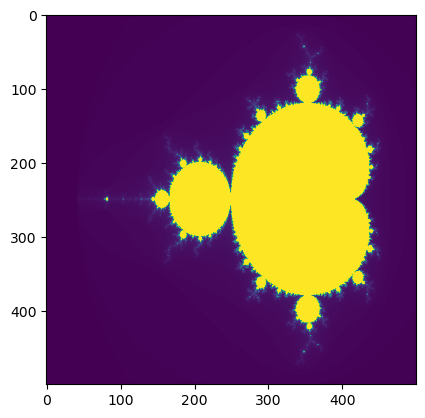

In [67]:
# Use unit tests to verify the functionality of the code. 
# Use a test framework such as py.test and/or nose.
# Example:

#$ pip install pytest

%matplotlib inline 
import numpy as np 
import matplotlib.pyplot as plt 

from mandlebrot import mandelbrot 

x = np.linspace(-2.25, 0.75, 500)
y = np.linspace(-1.25, 1.25, 500)
output = mandelbrot(x,y,200,False)

plt.imshow(output)

In [68]:
import numpy as np
from mandlebrot import mandelbrot

def test_mandelbrot_small():
    x = np.linspace(-2.25, 0.75, 10)
    y = np.linspace(-1.25, 1.25, 10)
    output = mandelbrot(x, y, 100, False)
    assert output.shape == (10, 10)

def test_mandelbrot_zero_outside():
    # The Mandelbrot set should be zero outside the "active" area
    x = np.linspace(1.5, 2.0, 10)
    y = np.linspace(1.5, 2.0, 10)
    output = mandelbrot(x, y, 100, False)
    assert np.all(output == 0.0)

def test_mandelbrot_incorrect_test():
    x = np.linspace(-1.5, -2.0, 10)
    y = np.linspace(-1.25, 1.25, 10)
    output = mandelbrot(x, y, 100, False)
    assert np.all(output == 0.0)
  

In [69]:
test_mandelbrot_small()

In [70]:
test_mandelbrot_zero_outside()

In [71]:
test_mandelbrot_incorrect_test()

# Notice that this test is incorrect. 

AssertionError: 

In [ ]:
# How to run all these tests? 

# > Call py.test or nosetests in the folder containing your project. 
# The tools will look for files named test_*() in the current folder. 

!py.test

============================= test session starts ==============================
platform darwin -- Python 3.12.2, pytest-7.4.4, pluggy-1.0.0
rootdir: /Users/mark/Desktop/Python & Data Analytics/Repositories/python-training-jpmorgan-1/notebooks
plugins: freezegun-0.4.2, anyio-4.10.0
collected 0 items                                                              

============================ no tests ran in 0.00s =============================


In [ ]:
# All python files can also be treated as modules, i.e. they can be imported in other Python files / notebooks. 

%%writefile mymodule.py

def my_function():
    return "Surprise!"

UsageError: Line magic function `%%writefile` not found.


In [ ]:
code = '''def my_function():
    return "Surprise!"
'''
with open('mymodule.py', 'w') as f:
    f.write(code)

In [ ]:
# Or create the file from the macOS terminal
cat > mymodule.py <<'PY'
def my_function():
    return "Surprise!"
PY

In [ ]:
# The python package index (PyPI) is a repository of software for the Python programming language.
# Official webpage https://pypi.python.org/pypi

CHAPTER 1 NOTES >

In [ ]:
# Chapter 1 > > 
# Nothing new 

CHAPTER 2 NOTES > 


We can approximatge the price of an ATMF straddle: 


$$ STRADDLE_{ATMF} \approx \frac{2}{\sqrt{2\pi}} F \times \sigma \sqrt(T) $$
$$ \sigma = implied volatility $$
$$ T = time-to-maturity $$
$$ F = forward of the underlier $$

In [ ]:
#Let's start with defining the straddle's implied volatility and time-to-maturity. Note that we will assume F is equal to 1 and the straddle price can be scaled accordingly. 
vol = 0.2 # Implied volatility
time = 1 # Time to maturity in years

In [ ]:
2*( ( 1 / (2 * 3.14) **0.5) * vol * time ** 0.5 ) 


0.15961737689352445

In [ ]:
# This is a lot to type again over again if you want to price several straddles. We can reduce this manual work if we define a function for this so that we can use it over and over. 

def straddle_price(vol, time) : 
    return 2 * ( ( 1 / (2 * 3.14) **0.5) * vol * time ** 0.5 )

# lets also make with dif name
def StraddlePricer(vol, time) : 
    return 2 * ( ( 1 / (2 * 3.14) **0.5) * vol * time ** 0.5 )

# Remember that straddle strategy involves buying both a call and a put option at the same strike price and expiration date. The price of the straddle is the sum of the prices of the call and put options.

In [ ]:
print( straddle_price( 0.2, 1.0 ) )
print( 2. * ( ( 1. / ( 2 * 3.14 ) ** 0.5 ) * vol * time ** 0.5 ) )
print( straddle_price( 0.2, 1.0 ) == ( 2. * ( ( 1. / ( 2 * 3.14 ) ** 0.5 ) * vol * time ** 0.5 ) ) )

0.15961737689352445
0.15961737689352445
True


In [ ]:
# Input order doesnt matter as long as we let the function know what we are using as inputs:

print(StraddlePricer(time=1.0, vol=0.2))
print(StraddlePricer( vol = 0.2, time = 1.0)) 

print(StraddlePricer(0.2, 1.0))


0.15961737689352445
0.15961737689352445
0.15961737689352445


In [ ]:
# But what if we want to default to certain inputs? By setting the initial inputs below wa are implicitly calling each of these arguments "oprtional". Initially we will make only time and optional argument (input) 

def StraddlePricer( vol, time = 1.0): 
    return 2.* ( ( 1 / (2*3.14) **0.5) * vol * time ** 0.5) 


In [ ]:
StraddlePricer(0.2)

0.15961737689352445

In [ ]:
def StraddlePricer(vol=0.2, time=1.0):
    return 2. * ((1/(2*3.14)**0.5)*vol * time ** 0.5)

In [ ]:
StraddlePricer()

0.15961737689352445

In [ ]:
StraddlePricer(0.22)

0.1755791145828769

In [ ]:
# Notice that the pi value we used is an approximation. We can use more precise value by importing the library;

import numpy as np 
import pandas as pd 
import datetime as dt 

In [ ]:
np.pi

3.141592653589793

In [ ]:
# numpy also has a handy function for square root calculations.
np.sqrt(4)

2.0

In [ ]:
# Now lets incorporate these libraries into our straddle pricer function.

def StraddlePricer(vol=0.2, time=1.0): 
    return 2. * ( ( 1/ np.sqrt(2 * np.pi) ) * vol * np.sqrt(time))

StraddlePricer()

0.1595769121605731

In [75]:
# The accuracy difference is regognizable.

StraddlePricer() - ( 2. * ( ( 1 / ( 2 * 3.14 ) ** 0.5 ) * vol * time ** 0.5 ) )

-4.046473295135633e-05

In [76]:
# Numpy can generate random values:

np.random.rand()

0.07049939238396252

In [77]:
# We can call dir on np to see what is included 
dir(np)

['ALLOW_THREADS',
 'BUFSIZE',
 'CLIP',
 'DataSource',
 'ERR_CALL',
 'ERR_DEFAULT',
 'ERR_IGNORE',
 'ERR_LOG',
 'ERR_PRINT',
 'ERR_RAISE',
 'ERR_WARN',
 'FLOATING_POINT_SUPPORT',
 'FPE_DIVIDEBYZERO',
 'FPE_INVALID',
 'FPE_OVERFLOW',
 'FPE_UNDERFLOW',
 'False_',
 'Inf',
 'Infinity',
 'MAXDIMS',
 'MAY_SHARE_BOUNDS',
 'MAY_SHARE_EXACT',
 'NAN',
 'NINF',
 'NZERO',
 'NaN',
 'PINF',
 'PZERO',
 'RAISE',
 'RankWarning',
 'SHIFT_DIVIDEBYZERO',
 'SHIFT_INVALID',
 'SHIFT_OVERFLOW',
 'SHIFT_UNDERFLOW',
 'ScalarType',
 'True_',
 'UFUNC_BUFSIZE_DEFAULT',
 'UFUNC_PYVALS_NAME',
 'WRAP',
 '_CopyMode',
 '_NoValue',
 '_UFUNC_API',
 '__NUMPY_SETUP__',
 '__all__',
 '__builtins__',
 '__cached__',
 '__config__',
 '__deprecated_attrs__',
 '__dir__',
 '__doc__',
 '__expired_functions__',
 '__file__',
 '__former_attrs__',
 '__future_scalars__',
 '__getattr__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 '_add_newdoc_ufunc',
 '_builtins',
 '_distributor_init',
 '_financi

In [80]:
# We can also price the straddle using the Monte Carlo method. 
# For that we need to generate a normally distributed set of random numbers to simulate the assetäs movement throught time 

def StraddlePricerMC(vol=0.2, time=1.0, mcPaths=100): 
    dailyVol = vol / np.sqrt(252.)
    resultSum = 0 
    for p in range (mcPaths):
        resultSum += np.abs(np.prod((1+np.random.normal(0, dailyVol, int(round(time*252)))))- 1)
    return resultSum / mcPaths

StraddlePricerMC()

0.17263659263525347

In [81]:
# The code above includes various new things in it. 

# Breaking down: 
#We know the variance scales linearly with time, so we can either:
    #1. Divide the variance by time and take the square root to get a daily volatility, or 
    #2. Take the square root of variance (volatility) and divide by the root of time. 
    
    # Generally, the latter is clearer and simpler to understand since we typically think in vol terms, but you are free to use whichever method you want. 
    
#Option 1 above:
np.sqrt(vol**2/252) 

0.012598815766974242

In [82]:
# Comparing the two methods:

vol = 0.2 
var = vol ** 2 
sqrtVarOverTime = np.sqrt(var/252)  
volOverSqrtTime = vol / np.sqrt(252)
valuesEqual = np.isclose(sqrtVarOverTime, volOverSqrtTime)
print( f'sqrtVarOverTime = {sqrtVarOverTime}\nvolOverSqrtTime = {volOverSqrtTime}\nAre they close? {valuesEqual}' )

sqrtVarOverTime = 0.012598815766974242
volOverSqrtTime = 0.01259881576697424
Are they close? True


In [83]:
#The next line isn't super exciting, but we set the default value of our cumulative sum to be 0. So we're just defining resultSum and setting it equal to 0. If we don't do this we'll get an error. 

resultSum = 0

In [84]:
#Next we have a loop. There are different types of loops we can use. Here we use a `for` loop, which says "iterate over each element in `range(mcPaths)`". But wait...what's `range(mcPaths)`? `range` is a native python function that will return an iterator over a list of ints starting at 0 and going to x-1.

range10 = range(10)
lst = list(range10)
print(lst)
print(len(lst))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
10


In [87]:
def straddlePricerMC(vol=0.2, time = 1.0, mcPaths=100):
    dailyVol = vol / np.sqrt(252)
    resultSum = 0
    for _ in range(mcPaths):
        resultSum += np.abs(np.prod(1+(np.random.normal(0, dailyVol, int(round(time*252)))))- 1)
    return resultSum / mcPaths

straddlePricerMC()

0.14354648801822983

In [88]:
help(np.random.normal)

Help on built-in function normal:

normal(...) method of numpy.random.mtrand.RandomState instance
    normal(loc=0.0, scale=1.0, size=None)

    Draw random samples from a normal (Gaussian) distribution.

    The probability density function of the normal distribution, first
    derived by De Moivre and 200 years later by both Gauss and Laplace
    independently [2]_, is often called the bell curve because of
    its characteristic shape (see the example below).

    The normal distributions occurs often in nature.  For example, it
    describes the commonly occurring distribution of samples influenced
    by a large number of tiny, random disturbances, each with its own
    unique distribution [2]_.

    .. note::
        New code should use the `~numpy.random.Generator.normal`
        method of a `~numpy.random.Generator` instance instead;
        please see the :ref:`random-quick-start`.

    Parameters
    ----------
    loc : float or array_like of floats
        Mean ("centre") o

In [89]:
np.random.normal()

-1.051821694836542

In [90]:
#Below we're going to call this method with a mean of zero (no drift) and a standard deviation of our daily vol, so that we can generate multiple days of returns. Specifically, we ask to generate the number of days to maturity.

time = 1 
nDays = time * 252
dailyVol = vol / np.sqrt(252) 
print(nDays) 

np.random.normal(0, dailyVol, nDays) 

252


array([-0.00648117, -0.00699028, -0.00446827,  0.0087004 , -0.0052509 ,
       -0.0033261 ,  0.0017321 , -0.01749239,  0.01498052,  0.01265939,
       -0.00399773,  0.00603626,  0.00814855,  0.00485139, -0.02405788,
       -0.01763306,  0.00420609, -0.00056495,  0.00404764,  0.01049955,
        0.00162151,  0.00198433, -0.00243402, -0.01971493,  0.01376413,
       -0.00685093, -0.00090425, -0.01204723,  0.00046799, -0.01585818,
        0.01131518, -0.00170244, -0.01906854, -0.00129027, -0.00787513,
        0.0145621 ,  0.00315172, -0.01326198,  0.01768374,  0.00230778,
       -0.0038296 ,  0.01071397, -0.01613362, -0.02544645, -0.01139069,
       -0.02218978, -0.00784347,  0.00668312, -0.02242085,  0.00190305,
       -0.00484613,  0.01137849,  0.00212274, -0.00290848, -0.00703069,
       -0.02162971,  0.03675722, -0.02915529,  0.01252014, -0.01401481,
       -0.02030939,  0.00177278, -0.00209364, -0.00163172, -0.00755417,
       -0.00983445,  0.00726283, -0.00797566,  0.00244118,  0.00

In [93]:
# Now, given we have an asset return timeseries, how much is a straddle worth? We're interested in the terminal value of the asset and because we assume the straddle is struck ATM, we can just take the absolute value of the asset's deviation from the initial value (in this case, 1) 

np.random.seed(42) # For reproducibility

returns = np.random.normal(0, dailyVol, time*252)
priceAtMaturity = np.prod(1 + returns) 
changeAtMaturity = priceAtMaturity - 1 
absChangeAtMaturity = np.abs(changeAtMaturity)
print(absChangeAtMaturity)

# All together in one line 
np.random.seed(42) 
print(np.abs(np.prod(1+(np.random.normal(0, dailyVol, time *252)))-1))

0.03008857382351271
0.03008857382351271


In [97]:
#Let's take a closer look at what we did above. This time, we're going to utilize another two libraries called pandas and perspective to make our life a little easier.

import pandas as pd
from perspective import psp 

simulateAsset = pd.DataFrame(np.random.normal(0, dailyVol, time * 252) +1, columns=['return'] )
simlateAsset['price'] = (1 * simulatedAsset['return']).cumprod()
psp( simulatedAsset)

ModuleNotFoundError: No module named 'perspective'

In [98]:
mcPaths = 100
resultSum = 0.
for _ in range(mcPaths):
    resultSum += np.abs( np.prod( 1 + np.random.normal( 0., dailyVol, time * 252 ) ) - 1 )
print( resultSum / mcPaths )

0.14729794955899883


In [99]:
# The price is pretty close to the price from our original pricer. More paths should help get us even closer. 

straddlePricerMC(mcPaths=2000)

0.15838729969079307

In [100]:
#2000 paths is a lot, but it looks like we're still not converging to the original price. If we add more paths there is a tradeoff with compute time. Luckily, Jupyter has made it really easy to see how fast our function is.

%timeit straddlePricerMC(mcPaths=2000)

15.9 ms ± 202 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [102]:
print(f"1 path: {straddlePricerMC(mcPaths=1)}")
print(f"2000 path: {straddlePricerMC(mcPaths=2000)}")
print(f"5000 path: {straddlePricerMC(mcPaths=5000)}")
print(f"10000 path: {straddlePricerMC(mcPaths=10000)}")
print(f"100000 path: {straddlePricerMC(mcPaths=100000)}")
print(f"Closed form approximation: {StraddlePricer()}")

1 path: 0.0032704229132995977
2000 path: 0.15560649116837347
5000 path: 0.1585187164737874
10000 path: 0.16077833924837492
100000 path: 0.15973234767394795
Closed form approximation: 0.1595769121605731


In [103]:
# Can we improve the above MC implementation? Of course! We can generate our random asset series in one go. Remember the `size` argument of the `np.random.normal` function 

nDays = time * 252
size = (nDays, 15)
simulatedAsset = pd.DataFrame(np.random.normal(0, dailyVol, size))
simulatedAsset = (1 + simulatedAsset).cumprod()

simulatedAsset.tail()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
247,0.848256,0.793209,1.127581,1.073237,1.022272,0.718426,1.313636,0.699854,0.901993,0.863114,0.903687,0.861975,0.914346,1.659214,0.896425
248,0.835351,0.784678,1.129241,1.067546,1.030476,0.725123,1.328502,0.699983,0.903506,0.853462,0.888664,0.856941,0.926957,1.657475,0.898420
249,0.827182,0.793118,1.120698,1.064426,1.053211,0.721471,1.326362,0.683081,0.915818,0.855609,0.889387,0.857674,0.913443,1.648874,0.893011
250,0.827661,0.793024,1.092301,1.059168,1.067210,0.715940,1.312220,0.678374,0.917915,0.838815,0.891686,0.853298,0.926068,1.618978,0.890845
251,0.824046,0.801045,1.088121,1.062177,1.075519,0.719218,1.290728,0.674397,0.917720,0.852273,0.874973,0.876455,0.924847,1.620286,0.864204


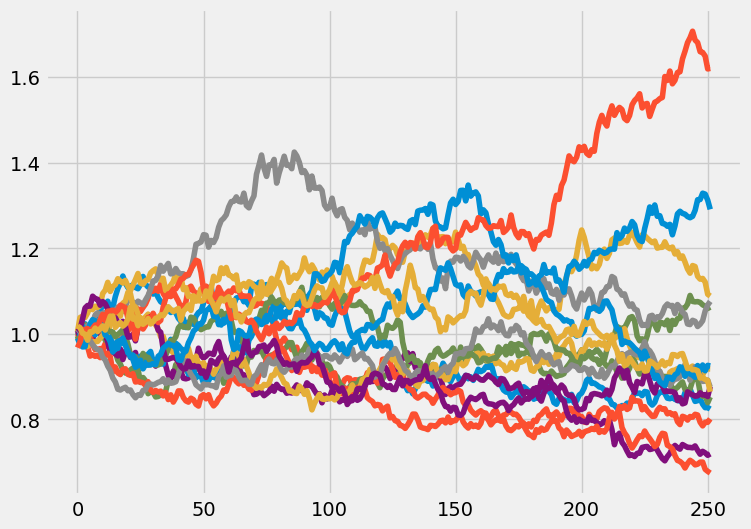

In [104]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.style.use('fivethirtyeight')

fig = plt.figure(figsize=(8,6))
ax = plt.axes()
_ = ax.plot(simulatedAsset)

In [105]:
def straddlePricerMCWithPD(vol=0.2, time=1, mcPaths=100000):
    dailyVol = vol / ( 252 ** 0.5 )
    randomPaths = pd.DataFrame( np.random.normal( 0, dailyVol, ( time*252, mcPaths ) ) )
    price = ( ( 1 + randomPaths ).prod() - 1 ).abs().sum() / mcPaths
    return price

straddlePricerMCWithPD()

0.15995411619675312

# Working with files. Chapter 3_ flights

In [163]:
from os import listdir 
from os.path import join 

listdir('.')

['4_webapi.ipynb',
 '9_3d_plotting.ipynb',
 '.pytest_cache',
 '5_website.ipynb',
 '3_flights.ipynb',
 'mandlebrot.py',
 '__pycache__',
 '6_financial_data.ipynb',
 '2_straddle.ipynb',
 '0_best_practices.ipynb',
 '1_basic.ipynb',
 'mymodule.py',
 'My_notes.ipynb',
 '7_advanced_plotting.ipynb',
 '8_altman_z_double_prime.ipynb']

In [164]:
listdir('../data')

['yield_curve.csv',
 'routes.csv',
 'data_norm.csv',
 'data_raw.csv',
 'airports.csv']

In [165]:
import pandas as pd 
pd.read_csv

<function pandas.io.parsers.readers.read_csv(filepath_or_buffer: 'FilePath | ReadCsvBuffer[bytes] | ReadCsvBuffer[str]', *, sep: 'str | None | lib.NoDefault' = <no_default>, delimiter: 'str | None | lib.NoDefault' = None, header: "int | Sequence[int] | None | Literal['infer']" = 'infer', names: 'Sequence[Hashable] | None | lib.NoDefault' = <no_default>, index_col: 'IndexLabel | Literal[False] | None' = None, usecols: 'UsecolsArgType' = None, dtype: 'DtypeArg | None' = None, engine: 'CSVEngine | None' = None, converters: 'Mapping[Hashable, Callable] | None' = None, true_values: 'list | None' = None, false_values: 'list | None' = None, skipinitialspace: 'bool' = False, skiprows: 'list[int] | int | Callable[[Hashable], bool] | None' = None, skipfooter: 'int' = 0, nrows: 'int | None' = None, na_values: 'Hashable | Iterable[Hashable] | Mapping[Hashable, Iterable[Hashable]] | None' = None, keep_default_na: 'bool' = True, na_filter: 'bool' = True, verbose: 'bool | lib.NoDefault' = <no_default

In [166]:
# What other "read" functions does pandas have? 

import re
regex = re.compile(r'read')
list(filter(regex.match, dir(pd)))

['read_clipboard',
 'read_csv',
 'read_excel',
 'read_feather',
 'read_fwf',
 'read_gbq',
 'read_hdf',
 'read_html',
 'read_json',
 'read_orc',
 'read_parquet',
 'read_pickle',
 'read_sas',
 'read_spss',
 'read_sql',
 'read_sql_query',
 'read_sql_table',
 'read_stata',
 'read_table',
 'read_xml']

In [167]:
routes = pd.read_csv(join('..', 'data', 'routes.csv'))
airports = pd.read_csv(join('..', 'data', 'airports.csv'))

In [168]:
routes.head()


,airline,airline_id,source,source_id,dest,dest_id,codeshare,stops,equipment
0,2B,410,AER,2965,KZN,2990,NaN,0,CR2
1,2B,410,ASF,2966,KZN,2990,NaN,0,CR2
2,2B,410,ASF,2966,MRV,2962,NaN,0,CR2
3,2B,410,CEK,2968,KZN,2990,NaN,0,CR2
4,2B,410,CEK,2968,OVB,4078,NaN,0,CR2


In [169]:
routes.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67663 entries, 0 to 67662
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   airline     67663 non-null  object
 1   airline_id  67663 non-null  object
 2   source      67663 non-null  object
 3   source_id   67663 non-null  object
 4   dest        67663 non-null  object
 5   dest_id     67663 non-null  object
 6   codeshare   14597 non-null  object
 7   stops       67663 non-null  int64 
 8   equipment   67645 non-null  object
dtypes: int64(1), object(8)
memory usage: 4.6+ MB


In [170]:
import missingno as msno

<Axes: >

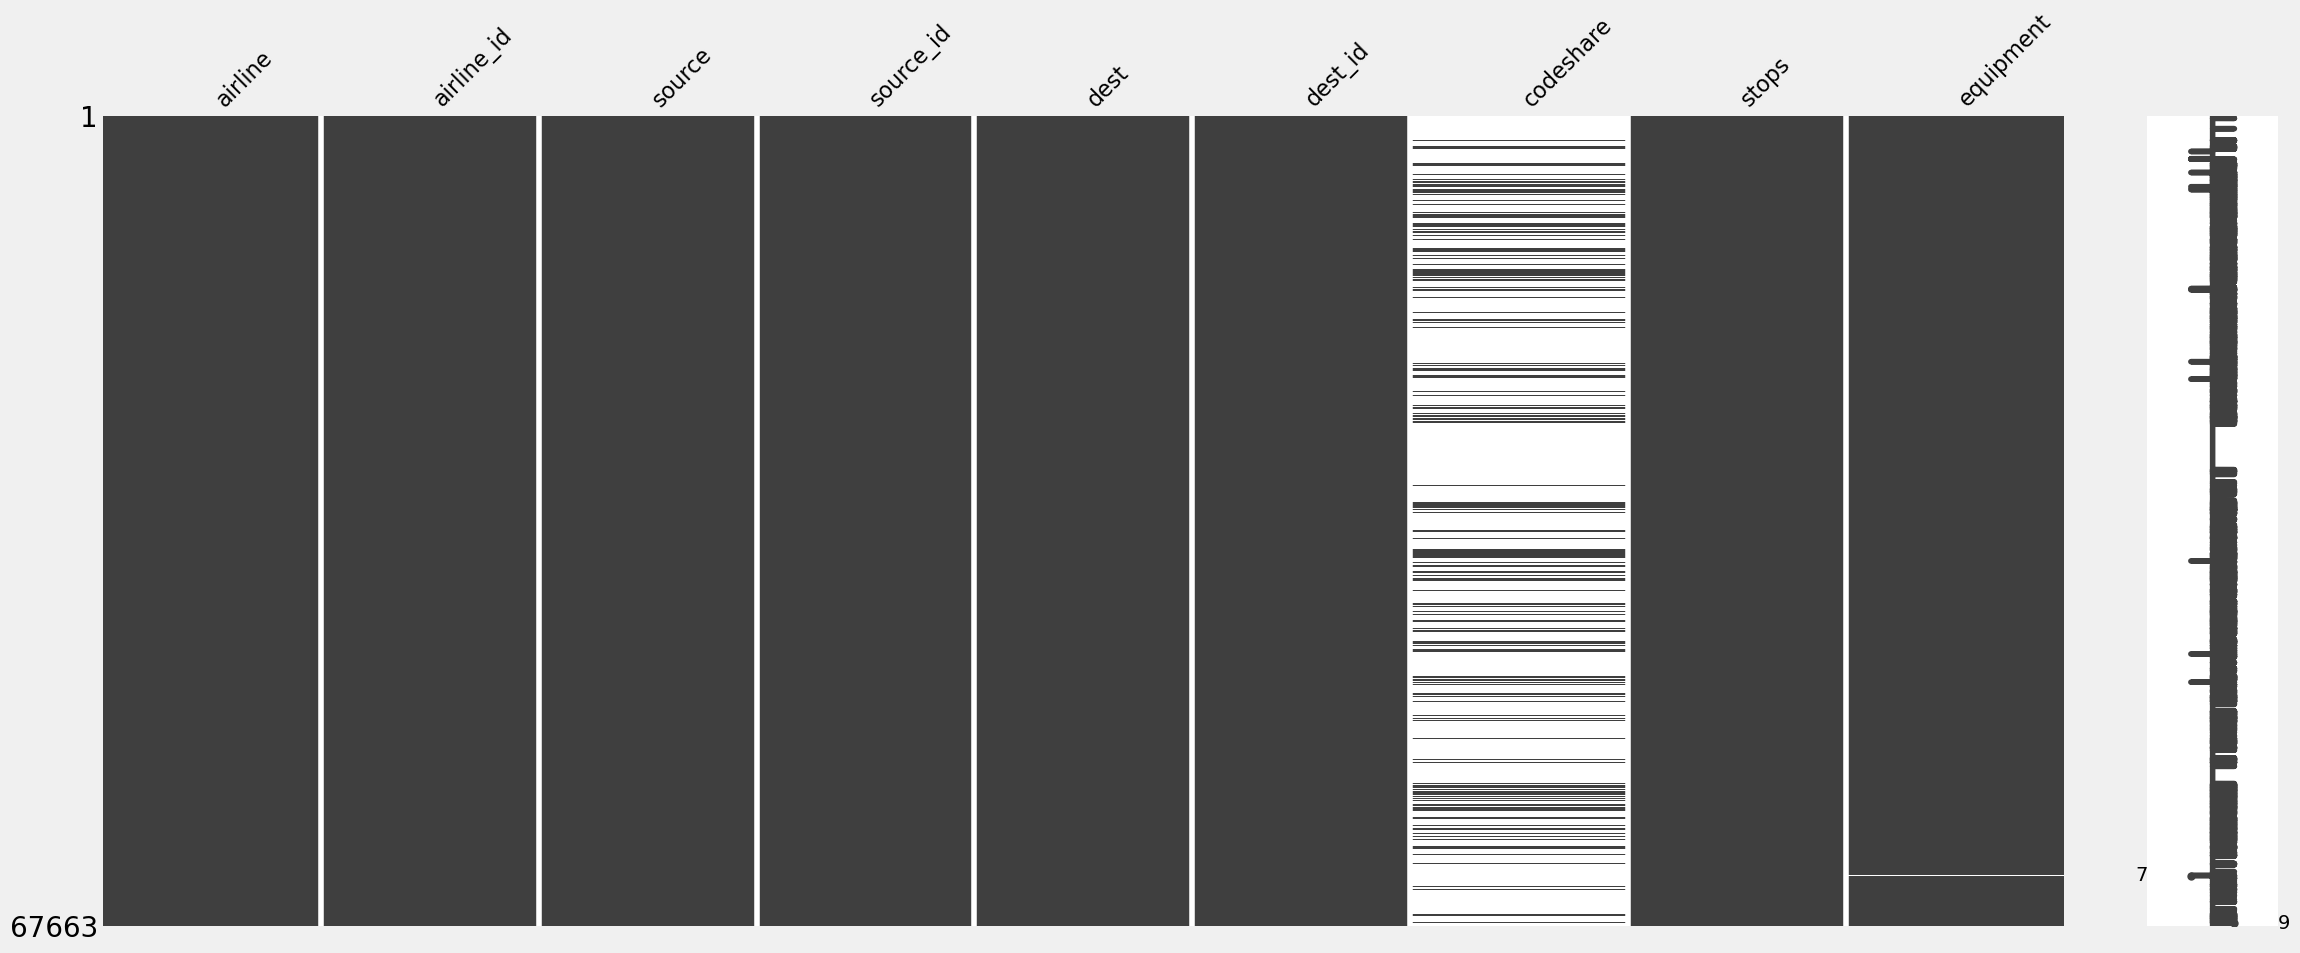

In [171]:
# `missingno` is a library that wraps together handy data utilities to get a visual summary of data completeness. We will only scratch the surface of this library.

%matplotlib inline 
msno.matrix(routes)

<Axes: >

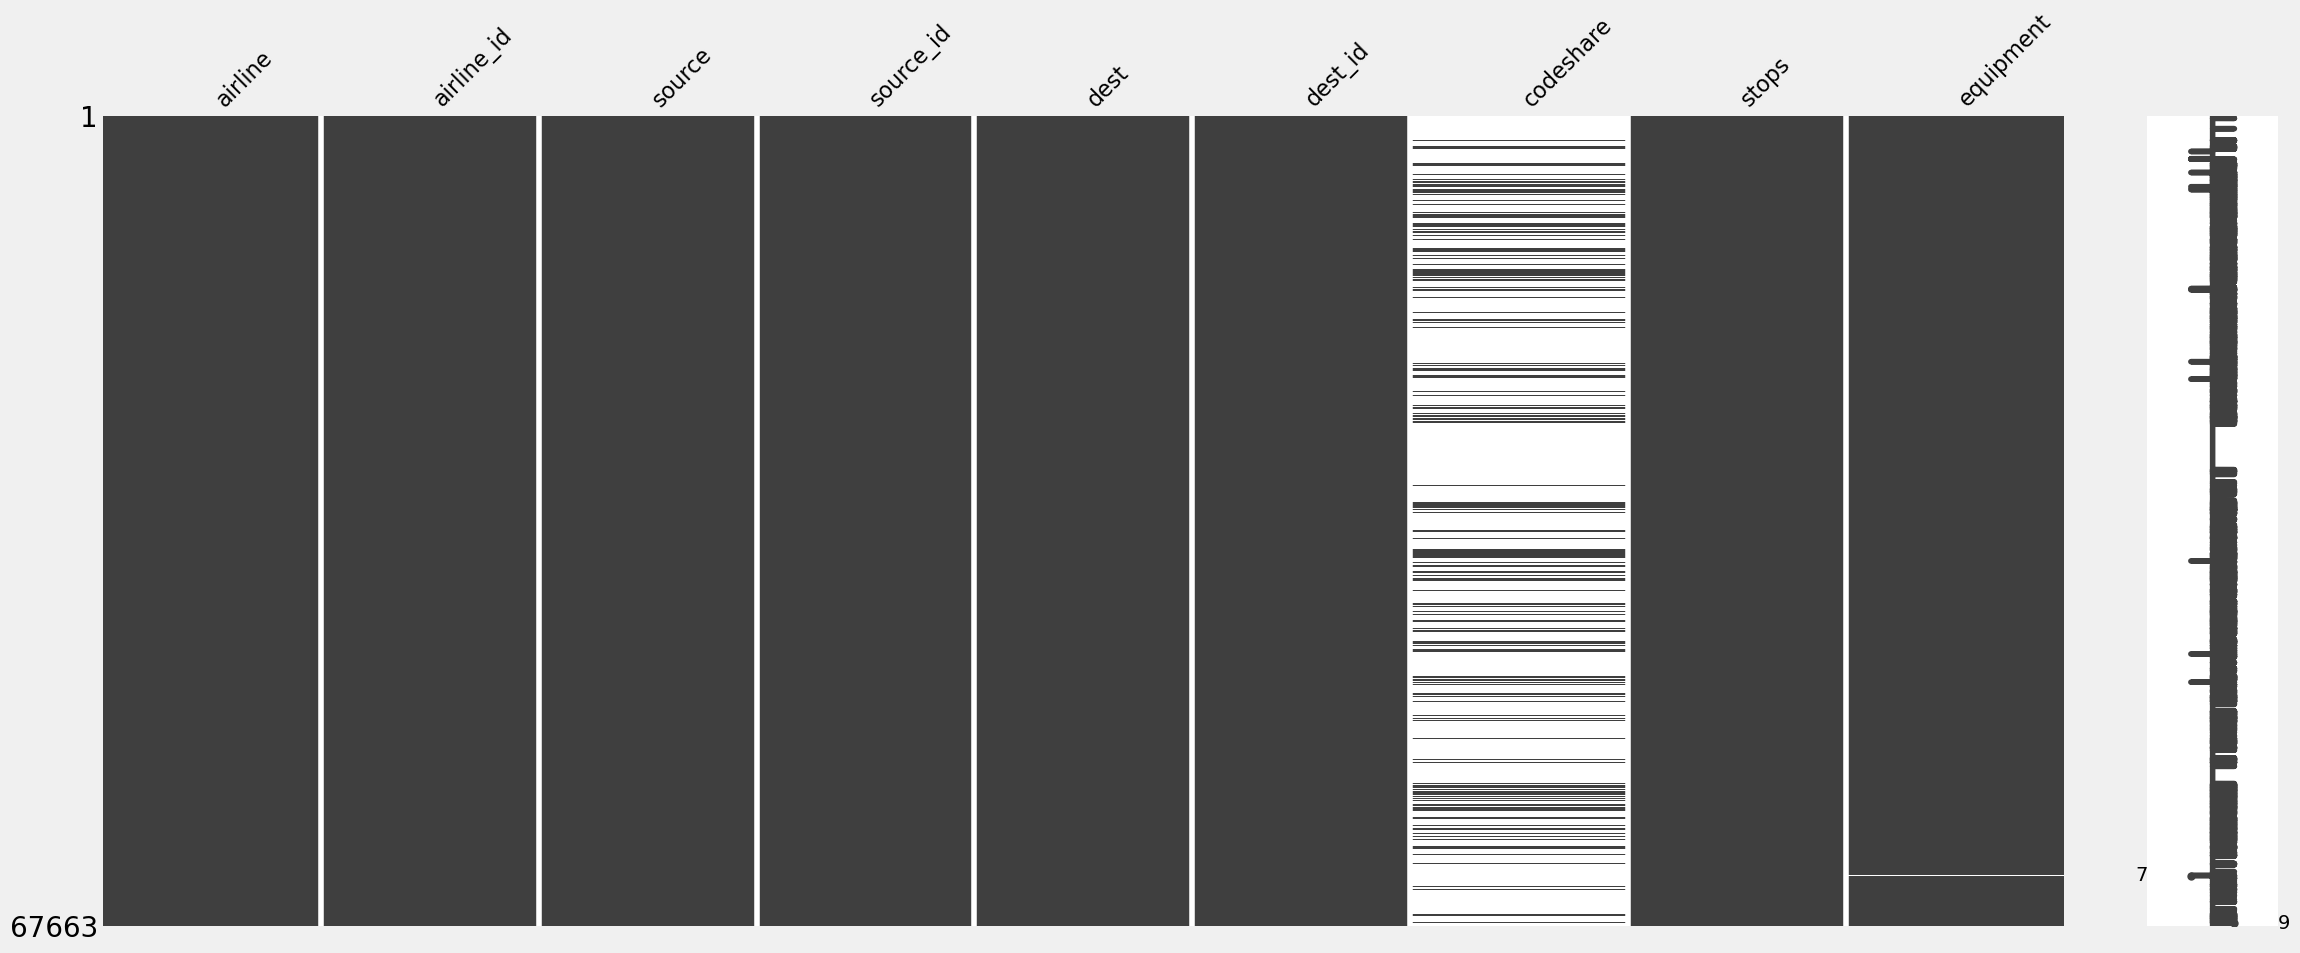

In [172]:
%matplotlib inline 
msno.matrix(routes)

In [173]:
#This gives a quick display to visually check out your data. The sparkline on the right shows the completeness of the data. Let's check out airports.

In [174]:
airports.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7698 entries, 0 to 7697
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        7698 non-null   int64  
 1   name      7698 non-null   object 
 2   city      7649 non-null   object 
 3   country   7698 non-null   object 
 4   IATA      7698 non-null   object 
 5   ICAO      7698 non-null   object 
 6   lat       7698 non-null   float64
 7   long      7698 non-null   float64
 8   altitude  7698 non-null   int64  
 9   timezone  7698 non-null   object 
 10  dst       7698 non-null   object 
 11  tzinfo    7698 non-null   object 
 12  type      7698 non-null   object 
 13  source    7698 non-null   object 
dtypes: float64(2), int64(2), object(10)
memory usage: 842.1+ KB


<Axes: >

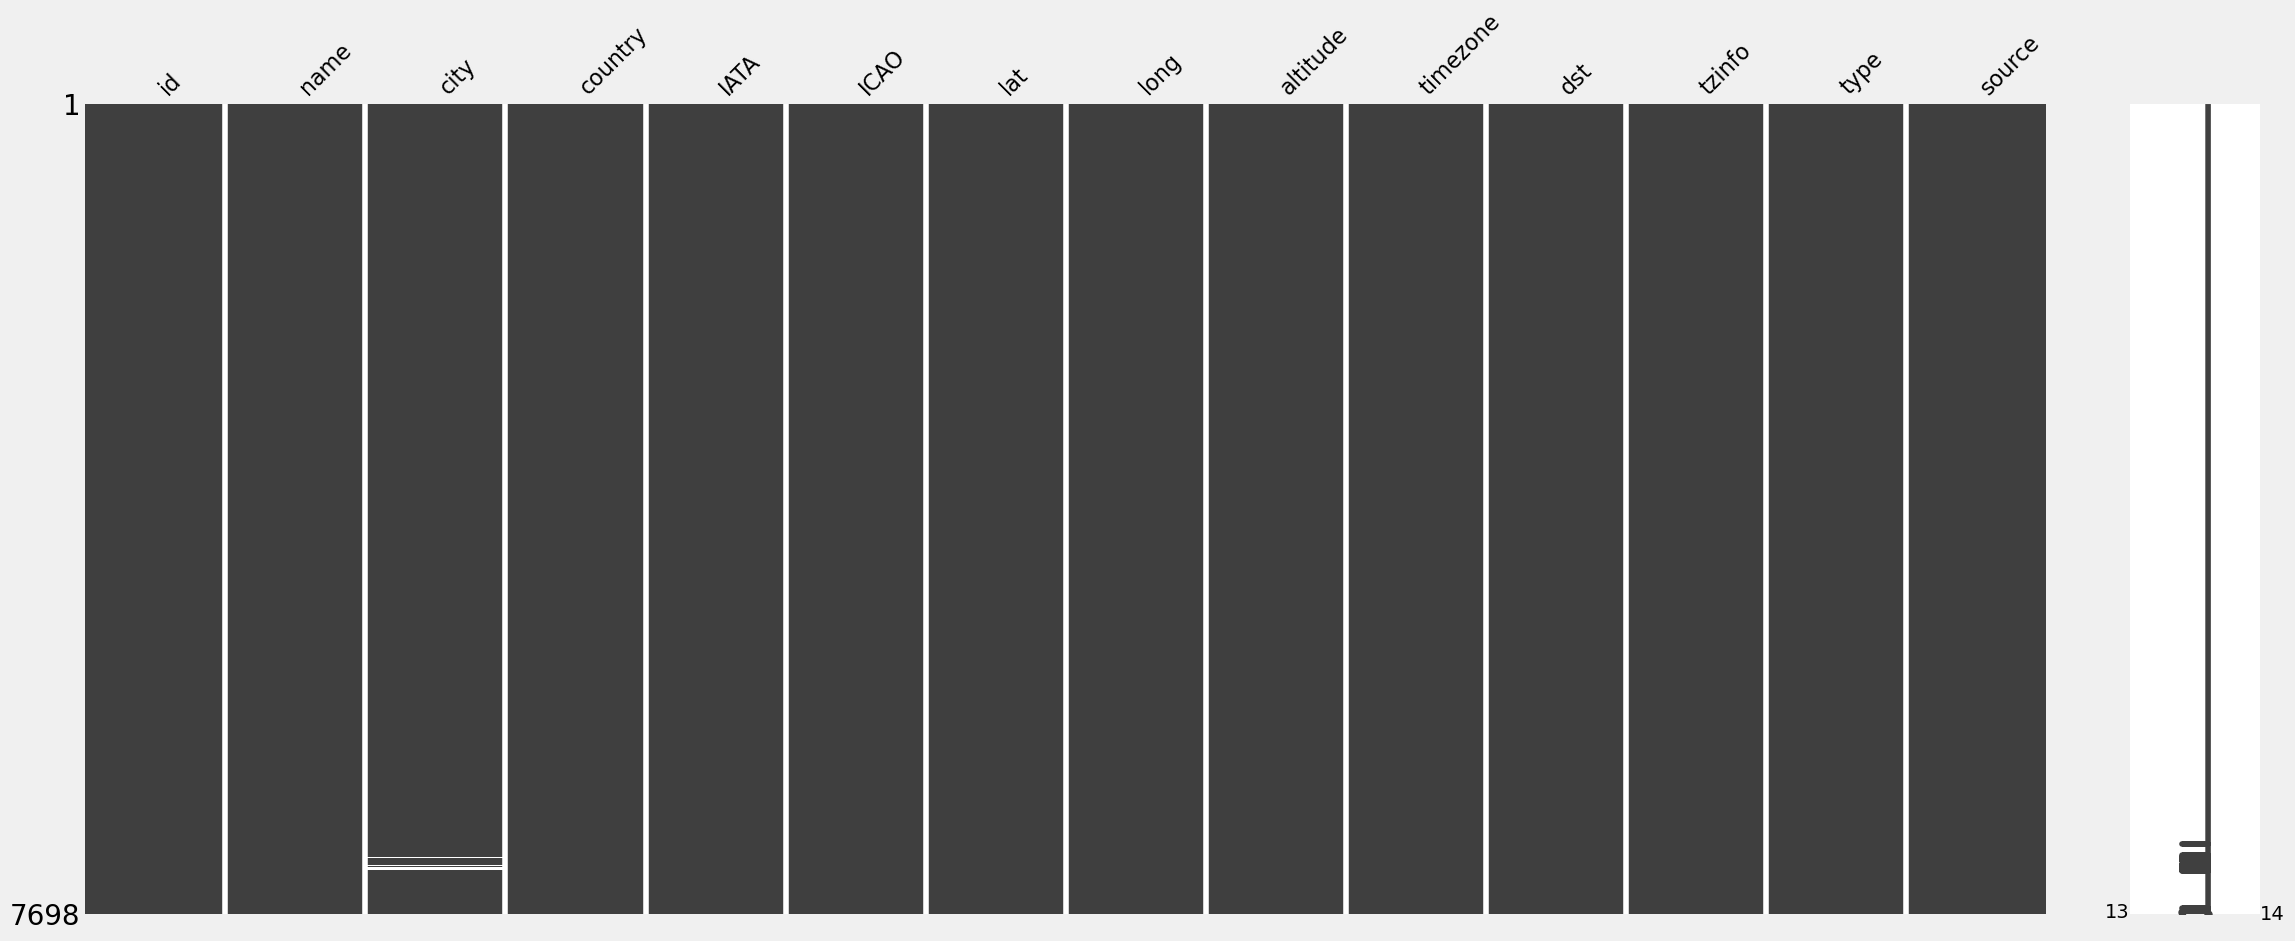

In [175]:
msno.matrix(airports)

In [176]:
airports[airports['IATA'] == 'LGA']

,id,name,city,country,IATA,ICAO,lat,long,altitude,timezone,dst,tzinfo,type,source
3497,3697,La Guardia Airport,New York,United States,LGA,KLGA,40.777199,-73.872597,21,-5,A,America/New_York,airport,OurAirports


In [177]:
#Awesome. How about finding some other things like the highest airport in the world, highest airport in the country that comes last alphabetically, and the highest airport in Australia.

highest = airports.sort_values('altitude', ascending=False).iloc[0]
highestInLastAlpha = airports.sort_values(['country', 'altitude'], ascending=[False, False]).iloc[0]
highestInAustralia = airports[airports['country'] == 'Australia'].sort_values('altitude', ascending=False).iloc[0]

In [178]:
print(f'Highest airport: \n{highest}\n\n')
print(f'Highest airport in the country that comes last alphabetically: \n{highestInLastAlpha}\n\n')
print(f'Highest airport in Australia: \n{highestInAustralia}\n\n')

Highest airport: 
id                             9310
name        Daocheng Yading Airport
city                       Daocheng
country                       China
IATA                            DCY
ICAO                           ZUDC
lat                       29.323056
long                     100.053333
altitude                      14472
timezone                          8
dst                               N
tzinfo                Asia/Shanghai
type                        airport
source                  OurAirports
Name: 6542, dtype: object


Highest airport in the country that comes last alphabetically: 
id                                                 1005
name        Robert Gabriel Mugabe International Airport
city                                             Harare
country                                        Zimbabwe
IATA                                                HRE
ICAO                                               FVHA
lat                                          -17.9

In [179]:
# Let's do some more practical things with this data like finding the 10 busiest routes in the world. 

busiest = routes.groupby(['source', 'dest']).count()['airline_id'].nlargest(10)
busiest

source  dest
ORD     ATL     20
ATL     ORD     19
HKT     BKK     13
ORD     MSY     13
ATL     MIA     12
AUH     MCT     12
BKK     HKG     12
CAN     HGH     12
DOH     BAH     12
HKG     BKK     12
Name: airline_id, dtype: int64

In [180]:
# We can merge in the names of the airports: 
busiest = pd.DataFrame(busiest).reset_index() 
busiest.head()

,source,dest,airline_id
0,ORD,ATL,20
1,ATL,ORD,19
2,HKT,BKK,13
3,ORD,MSY,13
4,ATL,MIA,12


In [ ]:
for sd in ['source', 'dest']:
    busiest = busiest.merge(airports[['IATA', 'name']].set_index('IATA'), how ='left', left_on=sd, right_on = 'IATA')
    
busiest

,source,dest,airline_id,name_x,name_y
0,ORD,ATL,20,Chicago O'Hare International Airport,Hartsfield Jackson Atlanta International Airport
1,ATL,ORD,19,Hartsfield Jackson Atlanta International Airport,Chicago O'Hare International Airport
2,HKT,BKK,13,Phuket International Airport,Suvarnabhumi Airport
3,ORD,MSY,13,Chicago O'Hare International Airport,Louis Armstrong New Orleans International Airport
4,ATL,MIA,12,Hartsfield Jackson Atlanta International Airport,Miami International Airport
5,AUH,MCT,12,Abu Dhabi International Airport,Muscat International Airport
6,BKK,HKG,12,Suvarnabhumi Airport,Hong Kong International Airport
7,CAN,HGH,12,Guangzhou Baiyun International Airport,Hangzhou Xiaoshan International Airport
8,DOH,BAH,12,Hamad International Airport,Bahrain International Airport
9,HKG,BKK,12,Hong Kong International Airport,Suvarnabhumi Airport


In [ ]:
# Chapter 4, WEBAPIs 

In [ ]:
import datetime
import pandas as pd
import json
import requests

coindeskURL = 'https://api.coindesk.com/v1/bpi/historical/close.json?'

# from API
start = datetime.date(2019, 1 ,1)
end = datetime.date(2019, 7, 1)

url = f'{coindeskURL}start={start:%Y-%m-%d}&end={end:%Y-%m-%d}'

print(f'Hitting this url:{url}')

result = requests.get(url)
result.content

Hitting this url:https://api.coindesk.com/v1/bpi/historical/close.json?start=2019-01-01&end=2019-07-01


ConnectionError: HTTPSConnectionPool(host='api.coindesk.com', port=443): Max retries exceeded with url: /v1/bpi/historical/close.json?start=2019-01-01&end=2019-07-01 (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x165157950>: Failed to resolve 'api.coindesk.com' ([Errno 8] nodename nor servname provided, or not known)"))

In [ ]:
# Chapter 7, advanced plotting 

# lets import some libraries first 

import pandas as pd 
import datetime as dt 
import seaborn as sns 
import numpy as np 
import matplotlib.pyplot as plt 
import datetime as dt 

%matplotlib inline 

In [ ]:
# Since we don't have access to some of the data that 
# #we do within JPM, we'll have to generate some data 
# #to plot. In this case, we're going to generate an 
# #approximation of Russell2k implied volatility and 
# HYG (iTraxx High Yield Bond ETF) prices.

vols = [0.3 , 0.06 ]
dailyVols = vols / np.sqrt(252)
corr = -0.4 
covars = [ 
        [dailyVols[0] ** 2, dailyVols[0] *dailyVols[1] * corr],
        [dailyVols[0] * dailyVols[1] *corr, dailyVols[1]**2]
]

randomSeries = np.random.multivariate_normal(( 0.001, 0 ), covars, 500).T

In [ ]:
randomSeries

array([[ 4.04379236e-02,  3.11591229e-02, -2.92733914e-02,
         1.98178914e-02, -1.55637527e-02,  1.08538783e-02,
        -4.72153054e-03,  5.63239140e-03, -5.10124725e-03,
        -2.36348823e-02,  1.35741958e-02, -1.31630273e-02,
         2.74278921e-02,  9.67169475e-03, -1.74717786e-02,
        -2.25214921e-02,  1.56967215e-02,  1.60393249e-02,
         1.32890185e-02,  9.42454274e-03,  1.30438305e-02,
        -1.13381842e-02, -3.88360399e-02,  3.65947716e-02,
         1.96683388e-02, -1.34095052e-02,  1.01826069e-02,
        -1.86492719e-02,  2.18281784e-02,  2.36292470e-04,
         1.26354581e-03, -1.92256019e-02,  9.91064071e-03,
         3.25838652e-03, -1.75407719e-02,  4.94587072e-03,
        -1.05374511e-02, -1.69154806e-02, -3.20163737e-02,
         2.96445694e-03, -6.64793408e-02, -3.29035558e-02,
         3.98831322e-03, -7.75194034e-04,  1.32667550e-02,
         2.90617581e-02,  9.25138364e-03,  1.14403161e-02,
         5.15404653e-03, -2.68645324e-02, -3.80442109e-0

In [ ]:
# We've got two return series, but we need to convert them to a time series for what they are meant to represent 

rtyVol = 0.2 * (1 + randomSeries[0]).cumprod()
hygPrice = 80 * (1 + randomSeries[1]).cumprod()

In [ ]:
# Let's see if they make sense 
# Often the easiest way to do that is to plot them. Many of the plotting libraries set up to operate / plot a DataFrame natively 

df = pd.DataFrame(np.array([rtyVol, hygPrice]).T, columns=["RTY.3m.Proxy.Implied.Vol", "HYG.spot"])


In [ ]:
df.head()

,RTY.3m.Proxy.Implied.Vol,HYG.spot
0,0.208088,79.738530
1,0.214571,79.327947
2,0.208290,79.902187
3,0.212418,79.516817
4,0.209112,79.725002


<Axes: >

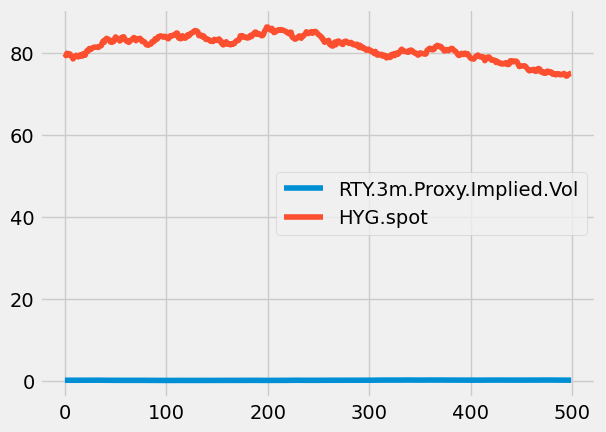

In [ ]:
df.plot()

In [ ]:
# So .. problem #1, these two series are not similar in magnitudes. We need to plot these on difference axes and while we are at it let's make it look a little better

plt.style.use('seaborn')
df.plot(secondary_y=["HYG.spot"], legend=True)


OSError: 'seaborn' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

<Axes: >

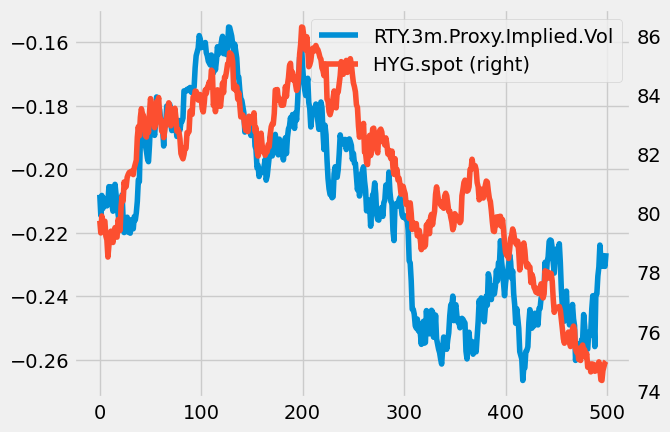

In [ ]:
# If we flip around RTY implied vol, we can see this inverse relationship a bit better 

df["RTY.3m.Proxy.Implied.Vol"] = df["RTY.3m.Proxy.Implied.Vol"] * -1
df.plot(secondary_y=["HYG.spot"], legend=True)

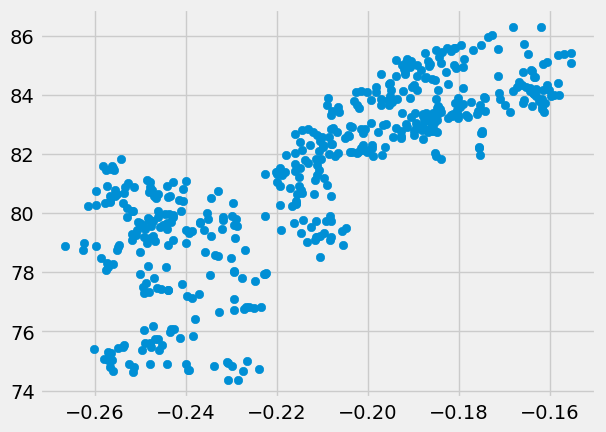

In [ ]:
# We can look at the scatter on levels pretty easility with matplotlib using matplotlib.pyplot.scatter 

plt.scatter(df[df.columns[0]], df[df.columns[1]])

<Axes: xlabel='HYG.spot', ylabel='RTY.3m.Proxy.Implied.Vol'>

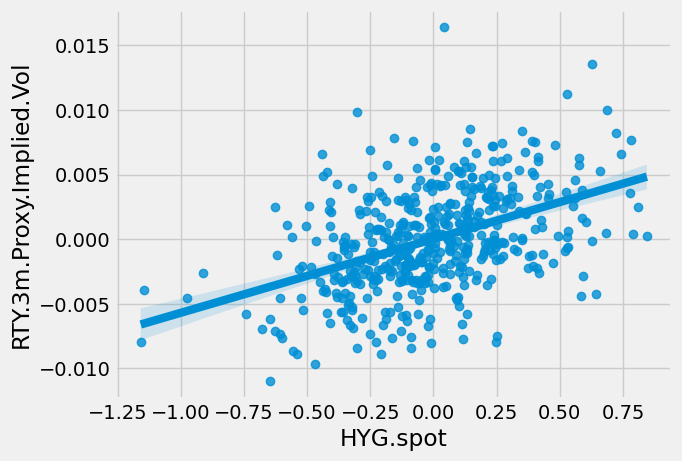

In [ ]:
fig, ax = plt.subplots( sharex=True )
sns.regplot( x="HYG.spot", y="RTY.3m.Proxy.Implied.Vol", data=df.diff(), ax=ax )

In [ ]:
#Unfortunately, the underlying regression data is not exposed in seaborn, so we will need to generate it ourselves using scipy

from scipy import stats

diff = df.diff().dropna()
slope, intercept, rvalue, pvalue, stderr = stats.linregress(diff["HYG.spot"], diff["RTY.3m.Proxy.Implied.Vol"])
print( "R^2 = {r:.3f}".format( r=rvalue ) )
print( 'y = {m:.3f}x {sign} {b:.3f}'.format( m=slope, sign="+" if intercept >= 0 else "-", b=abs(intercept) ) )

R^2 = 0.448
y = 0.006x + 0.000


In [ ]:
# What if we want to interact with the plot, such as zooming in, inspect the values etc. This is where plotply comes handy
from plotly.offline import download_plotlyjs, init_notebook_mode, iplot
import plotly.tools as tls
init_notebook_mode(connected=True)
# Here we can convert our matplotlib object to a plotly object 
plotlyFig = tls.mpl_to_plotly(fig)

# Add annotation so you have the regression stats 
plotlyFig['layout']['annotations'] = [
    dict( 
         x=18,
         y=-2,
         showarrow=False,
         text = 'R^2 = {:.3f}'.format(rvalue)
         ),
    dict(
        x=18,
        y=-2.6,
        showarrow = False, 
        text = 'y = {m:.3f}x {sign} {b:.3f}'.format(m=slope, sign="+" if intercept >=0 else "-", b=abs(intercept)) 
    )
]
iplot(plotlyFig)

In [ ]:
#2d plots are cool but 3d plots.... Below is an example of plotting a vol surface from start to finish.

c = [0.8023,0.814,0.8256,0.8372,0.8488,0.8605,0.8721,0.8837,0.8953,0.907,0.9186,0.9302,0.9419,0.9535,0.9651,0.9767,0.9884,1,1.0116,1.0233,1.0349,1.0465,1.0581,1.0698,1.0814,1.093,1.1047,1.1163,1.1279,1.1395,1.1512,1.1628,1.1744,1.186,1.1977,1.2093]
i = [ dt.datetime(2019,8,2),  dt.datetime(2019,8,9),  dt.datetime(2019,8,16),  dt.datetime(2019,8,23),  dt.datetime(2019,8,30),  dt.datetime(2019,9,6),  dt.datetime(2019,9,20),  dt.datetime(2019,10,18),  dt.datetime(2019,11,15),  dt.datetime(2019,12,20),  dt.datetime(2019,12,31),  dt.datetime(2020,1,17),  dt.datetime(2020,3,20),  dt.datetime(2020,3,31),  dt.datetime(2020,6,19) ]
d = [ [0.4244,0.4016,0.3796,0.3584,0.3381,0.3187,0.3002,0.2827,0.2662,0.2508,0.2363,0.2229,0.2105,0.1991,0.1888,0.1794,0.171,0.1636,0.157,0.1513,0.1465,0.1425,0.1393,0.1368,0.135,0.1338,0.1331,0.1329,0.133,0.1334,0.1341,0.135,0.136,0.1372,0.1384,0.1396],
    [0.4006,0.3777,0.3556,0.3343,0.3139,0.2944,0.2759,0.2583,0.2418,0.2263,0.2118,0.1983,0.1859,0.1745,0.1641,0.1547,0.1463,0.1388,0.1322,0.1265,0.1216,0.1176,0.1143,0.1118,0.11,0.1088,0.1081,0.1078,0.108,0.1084,0.1092,0.1101,0.1112,0.1123,0.1136,0.1149],
    [0.3431,0.3257,0.3089,0.2927,0.277,0.2621,0.2477,0.2341,0.2212,0.2089,0.1974,0.1866,0.1765,0.1671,0.1584,0.1504,0.1431,0.1364,0.1303,0.1248,0.1198,0.1154,0.1116,0.1083,0.1055,0.1032,0.1013,0.0998,0.0986,0.0977,0.0971,0.0966,0.0964,0.0963,0.0963,0.0965],
    [0.3124,0.298,0.284,0.2705,0.2574,0.2449,0.2328,0.2213,0.2104,0.1999,0.1901,0.1807,0.1719,0.1637,0.156,0.1488,0.1421,0.136,0.1304,0.1253,0.1206,0.1165,0.1129,0.1098,0.1072,0.1049,0.1031,0.1015,0.1003,0.0994,0.0988,0.0983,0.098,0.0979,0.0978,0.0979],
    [0.2955,0.283,0.2708,0.259,0.2475,0.2365,0.2259,0.2158,0.206,0.1968,0.1879,0.1795,0.1716,0.1641,0.1571,0.1505,0.1443,0.1385,0.1332,0.1284,0.124,0.1201,0.1167,0.1137,0.1111,0.1089,0.1071,0.1056,0.1044,0.1034,0.1027,0.1022,0.1019,0.1018,0.1017,0.1018],
    [0.2866,0.2752,0.264,0.2532,0.2427,0.2326,0.2228,0.2134,0.2044,0.1958,0.1876,0.1798,0.1724,0.1653,0.1587,0.1524,0.1465,0.141,0.1359,0.1313,0.1271,0.1233,0.12,0.1171,0.1145,0.1124,0.1106,0.1091,0.1079,0.1069,0.1062,0.1057,0.1054,0.1052,0.1051,0.1051],
    [0.2729,0.2632,0.2538,0.2446,0.2357,0.227,0.2187,0.2106,0.2028,0.1954,0.1882,0.1813,0.1748,0.1685,0.1626,0.1569,0.1516,0.1465,0.1418,0.1376,0.1336,0.1301,0.127,0.1242,0.1218,0.1197,0.1179,0.1164,0.1152,0.1143,0.1135,0.113,0.1126,0.1124,0.1122,0.1122],
    [0.2548,0.2473,0.24,0.2329,0.226,0.2192,0.2126,0.2063,0.2001,0.1941,0.1883,0.1827,0.1773,0.1721,0.167,0.1622,0.1576,0.1532,0.149,0.1452,0.1416,0.1383,0.1354,0.1327,0.1303,0.1281,0.1262,0.1246,0.1232,0.122,0.121,0.1202,0.1195,0.119,0.1186,0.1183],
    [0.2482,0.242,0.2359,0.2299,0.2241,0.2184,0.2128,0.2074,0.2021,0.1969,0.1919,0.187,0.1823,0.1777,0.1733,0.169,0.1649,0.1608,0.157,0.1535,0.1501,0.1471,0.1442,0.1415,0.1391,0.1369,0.135,0.1332,0.1316,0.1303,0.1291,0.128,0.1271,0.1263,0.1257,0.1252],
    [0.2331,0.2278,0.2227,0.2176,0.2127,0.2078,0.2031,0.1984,0.1939,0.1895,0.1851,0.1809,0.1768,0.1728,0.1689,0.1652,0.1615,0.158,0.1547,0.1516,0.1486,0.1459,0.1433,0.1409,0.1387,0.1367,0.1349,0.1332,0.1317,0.1303,0.1291,0.128,0.127,0.1261,0.1254,0.1247],
    [0.2313,0.2262,0.2212,0.2163,0.2115,0.2068,0.2022,0.1977,0.1932,0.1889,0.1847,0.1806,0.1766,0.1727,0.1689,0.1653,0.1617,0.1582,0.155,0.152,0.1491,0.1464,0.1438,0.1415,0.1393,0.1373,0.1354,0.1337,0.1322,0.1308,0.1296,0.1284,0.1274,0.1266,0.1258,0.1251],
    [0.2302,0.2253,0.2206,0.216,0.2114,0.2069,0.2026,0.1983,0.1941,0.19,0.186,0.1821,0.1783,0.1745,0.1709,0.1674,0.164,0.1607,0.1576,0.1546,0.1518,0.1492,0.1467,0.1444,0.1423,0.1403,0.1384,0.1367,0.1351,0.1337,0.1324,0.1313,0.1302,0.1293,0.1285,0.1277],
    [0.229,0.2249,0.2209,0.2169,0.213,0.2091,0.2054,0.2017,0.1981,0.1946,0.1911,0.1877,0.1845,0.1812,0.1781,0.175,0.172,0.1691,0.1664,0.1637,0.1611,0.1587,0.1563,0.1541,0.152,0.15,0.148,0.1462,0.1445,0.143,0.1415,0.1401,0.1388,0.1376,0.1365,0.1355],
    [0.2289,0.2249,0.2209,0.2171,0.2133,0.2096,0.2059,0.2023,0.1988,0.1953,0.192,0.1887,0.1855,0.1823,0.1793,0.1763,0.1733,0.1705,0.1678,0.1651,0.1626,0.1602,0.1579,0.1557,0.1535,0.1515,0.1496,0.1478,0.1461,0.1445,0.143,0.1415,0.1402,0.139,0.1379,0.1368],
    [0.2239,0.2207,0.2175,0.2143,0.2112,0.2082,0.2051,0.2022,0.1993,0.1964,0.1936,0.1909,0.1882,0.1855,0.1829,0.1804,0.1779,0.1755,0.1731,0.1708,0.1685,0.1663,0.1642,0.1622,0.1601,0.1582,0.1563,0.1545,0.1527,0.151,0.1494,0.1478,0.1464,0.1449,0.1436,0.1423]
]
df2 = pd.DataFrame(d, columns=c, index=i)

In [ ]:
df2.head()

,0.8023,0.8140,0.8256,0.8372,0.8488,0.8605,0.8721,0.8837,0.8953,0.9070,...,1.1047,1.1163,1.1279,1.1395,1.1512,1.1628,1.1744,1.1860,1.1977,1.2093
2019-08-02,0.4244,0.4016,0.3796,0.3584,0.3381,0.3187,0.3002,0.2827,0.2662,0.2508,...,0.1331,0.1329,0.1330,0.1334,0.1341,0.1350,0.1360,0.1372,0.1384,0.1396
2019-08-09,0.4006,0.3777,0.3556,0.3343,0.3139,0.2944,0.2759,0.2583,0.2418,0.2263,...,0.1081,0.1078,0.1080,0.1084,0.1092,0.1101,0.1112,0.1123,0.1136,0.1149
2019-08-16,0.3431,0.3257,0.3089,0.2927,0.2770,0.2621,0.2477,0.2341,0.2212,0.2089,...,0.1013,0.0998,0.0986,0.0977,0.0971,0.0966,0.0964,0.0963,0.0963,0.0965
2019-08-23,0.3124,0.2980,0.2840,0.2705,0.2574,0.2449,0.2328,0.2213,0.2104,0.1999,...,0.1031,0.1015,0.1003,0.0994,0.0988,0.0983,0.0980,0.0979,0.0978,0.0979
2019-08-30,0.2955,0.2830,0.2708,0.2590,0.2475,0.2365,0.2259,0.2158,0.2060,0.1968,...,0.1071,0.1056,0.1044,0.1034,0.1027,0.1022,0.1019,0.1018,0.1017,0.1018


In [ ]:
import plotly.graph_objs as go

fig = go.Figure(
    data=[ go.Surface(
        z=df2.values.tolist(),
        y=df2.columns.values,
        x=df2.index.astype(str).values.tolist()
    )],
    layout=dict(
        title = 'Vol Surface', 
        autosize = True,
        width = 900,
        height = 700,
        margin = dict(
            l = 65,
            r = 50,
            b = 65,
            t = 90
        ),
        scene = dict(
            aspectratio = dict(
                x = 1,
                y = 1,
                z = 0.667
            )
        )
    ))

go.FigureWidget(fig)

ImportError: Please install anywidget to use the FigureWidget class

In [ ]:
# Chapter 8, Altman z 

In [ ]:
#When it was initially developed there were some crude cutoffs for the scores - above 2.6 and the firm was "healthy", between 1.1-2.6 was the "grey area", and below 1.1 and the firm as at risk of bankruptcy. However, over time that crude scale was refined. One of the unique things about the Altman Z" Score today is that we have a mapping to conventional credit ratings. 


$$ Z” = 6.56x_1 +3.26x_2 + 6.72x_3 + 1.05x_4 $$
$$ \textrm{Where:} $$
$$ x_1 = \textrm{Working Capital / Total Assets} $$
$$ x_2 = \textrm{Retained Earnings / Total Assets} $$
$$ x_3 = \textrm{EBIT / Total Assets} $$
$$ x_4 = \textrm{Market Value of Equity / Total Liabilities} $$

In [184]:
import pyEX as p 
c = p.Client(api_token="pk_353fe2ce67cd4c16b30a748ff783c865", version="v1")

ModuleNotFoundError: No module named 'pyEX'

In [185]:
ticker = "aapl"
incomeStatement = c.incomeStatementDF(ticker)
balanceSheet = c.balanceSheetDF(ticker)
cfStatement = c.cashFlowDF(ticker)
stats = c.keyStats(ticker)

AttributeError: 'list' object has no attribute 'incomeStatementDF'

In [186]:
x1 = ( balanceSheet["currentAssets"][0] - balanceSheet["totalCurrentLiabilities"][0] ) / balanceSheet["totalAssets"][0]

NameError: name 'balanceSheet' is not defined

In [188]:
import pandas as pd
import numpy as np

import plotly.graph_objs as go

df = pd.read_csv('../data/yield_curve.csv')
xlist = list(df["x"].dropna())
ylist = list(df["y"].dropna())

del df["x"]
del df["y"]

zlist = []
for row in df.iterrows():
    index, data = row
    zlist.append(data.tolist())


In [189]:
z_secondary_beginning = [z[1] for z in zlist if z[0] == "None"]
z_secondary_end = [z[0] for z in zlist if z[0] != "None"]
z_secondary = z_secondary_beginning + z_secondary_end
x_secondary = ["3-month"] * len(z_secondary_beginning) + ["1-month"] * len(
    z_secondary_end
)
y_secondary = ylist

trace1 = dict(
    type="surface",
    x=xlist,
    y=ylist,
    z=zlist,
    hoverinfo="x+y+z",
    lighting={
        "ambient": 0.95,
        "diffuse": 0.99,
        "fresnel": 0.01,
        "roughness": 0.01,
        "specular": 0.01,
    },
    colorscale=[
        [0, "rgb(230,245,254)"],
        [0.4, "rgb(123,171,203)"],
        [0.8, "rgb(40,119,174)"],
        [1, "rgb(37,61,81)"],
    ],
    opacity=0.7,
    showscale=False,
    scene="scene",
)

trace2 = dict(
    type="scatter3d",
    mode="lines",
    x=x_secondary,
    y=y_secondary,
    z=z_secondary,
    hoverinfo="x+y+z",
    line=dict(color="#444444"),
)

data = [trace1, trace2]
layout = dict(
    autosize=True,
    font=dict(size=12, color="#CCCCCC"),
    margin=dict(t=5, l=5, b=5, r=5),
    showlegend=False,
    hovermode="closest",
    scene=dict(
        aspectmode="manual",
        aspectratio=dict(x=2, y=5, z=1.5),
        xaxis={
            "showgrid": True,
            "title": "",
            "type": "category",
            "zeroline": False,
            "categoryorder": "array",
            "categoryarray": list(reversed(xlist)),
        },
        yaxis={"showgrid": True, "title": "", "type": "date", "zeroline": False},
    ),
)
figure = dict(data=data, layout=layout)

go.FigureWidget(figure)

ImportError: Please install anywidget to use the FigureWidget class